# Scoring Workflow Demo

This notebook demonstrates the core scoring workflow for `sortscore` using the bundled demo dataset.

We will run:

`sortscore score -n EXPERIMENT_NAME -e experiment_setup.csv -c config.json`

Then you can inspect:
- Summary stats JSON
- The first few rows of score tables
- Codon and amino-acid heatmap visualizations

## About the demo data

This dataset comes from one sorting experiment using NNN mutagenesis (all codons represented) for deep mutational scanning (DMS) of the GLI2 DNA-binding domain (DBD).

The experiment covers one-fifth of the DBD because this region was targeted by a single oligo.

Count files include unique counts from 3 technical replicates.

## Prerequisites

This notebook assumes `sortscore` is installed and available in the same Python environment as the Jupyter kernel.

Recommended setup (outside this notebook, in terminal from repository root):
```bash
python -m venv .venv
source .venv/bin/activate
pip install -e .
pip install ipykernel
python -m ipykernel install --user --name=sortscore-venv --display-name="Python (sortscore venv)"
```

After setup, select that kernel for this notebook.

In [1]:
import importlib.util
import shutil

cli_path = shutil.which("sortscore")
pkg_ok = importlib.util.find_spec("sortscore") is not None

if cli_path or pkg_ok:
    print("sortscore is installed in this environment.")
    if cli_path:
        print(f"CLI path: {cli_path}")
else:
    print("sortscore is not installed in this environment.")
    print("See installation guide: docs/installation.md")

sortscore is installed in this environment.
CLI path: /Users/c.chitwood/code/sortscore/venv/bin/sortscore


## 1) Set run inputs

Update these variables if your files are in a different location.

In [2]:
from pathlib import Path

EXPERIMENT_NAME = "demo"
EXPERIMENT_SETUP_PATH = "demo_data/GLI2_oPool5b/experiment_setup.csv"
CONFIG_PATH = "demo_data/GLI2_oPool5b/config.json"

def resolve_path(path_str):
    path = Path(path_str)
    candidates = [path, Path("..") / path]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    return path

EXPERIMENT_SETUP_FILE = resolve_path(EXPERIMENT_SETUP_PATH)
CONFIG_FILE = resolve_path(CONFIG_PATH)

print(f"experiment_setup: {EXPERIMENT_SETUP_FILE}")
print(f"config: {CONFIG_FILE}")

experiment_setup: /Users/c.chitwood/code/sortscore/demo_data/GLI2_oPool5b/experiment_setup.csv
config: /Users/c.chitwood/code/sortscore/demo_data/GLI2_oPool5b/config.json


## 2) Run scoring workflow

This executes the full scoring workflow using the paths above.

In [3]:
!sortscore score -n {EXPERIMENT_NAME} -e {EXPERIMENT_SETUP_FILE} -c {CONFIG_FILE}

INFO:root:Using mutagenesis_type: 'codon'
INFO:root:Loaded counts for 3 replicates.
Counts loaded.
INFO:sortscore.utils.analysis_logger:Analysis logger initialized: demo_20260623_003002
INFO:root:Using mutagenesis_type: 'codon'
INFO:root:Processing DNA workflow
INFO:root:Calculated DNA scores for 2081 variants.
INFO:root:Saved DNA scores to /Users/c.chitwood/code/sortscore/demo_data/GLI2_oPool5b/output/scores/demo_dna_scores.csv
INFO:sortscore.utils.analysis_logger:Logged output file: dna_scores -> demo_dna_scores.csv
INFO:root:Saved stats to /Users/c.chitwood/code/sortscore/demo_data/GLI2_oPool5b/output/scores/demo_dna_stats.json
INFO:sortscore.utils.analysis_logger:Logged output file: dna_statistics -> demo_dna_stats.json
INFO:root:Calculated statistics on final DNA scores
INFO:root:Processing AA workflow...
INFO:root:Loading DNA scores from /Users/c.chitwood/code/sortscore/demo_data/GLI2_oPool5b/output/scores/demo_dna_scores.csv for AA aggregation
INFO:root:Aggregated to 695 unique 

## 3) Resolve output files


In [4]:
import json
import pandas as pd
from IPython.display import Image, Markdown, display

with open(CONFIG_FILE, "r", encoding="utf-8") as f:
    config = json.load(f)

output_dir_cfg = Path(config.get("output_dir", "output"))
if output_dir_cfg.is_absolute():
    output_dir = output_dir_cfg
else:
    output_dir = (CONFIG_FILE.parent / output_dir_cfg).resolve()

scores_dir = output_dir / "scores"
figures_dir = output_dir / "figures"

aa_stats_file = scores_dir / f"{EXPERIMENT_NAME}_aa_stats.json"
dna_stats_file = scores_dir / f"{EXPERIMENT_NAME}_dna_stats.json"
aa_scores_file = scores_dir / f"{EXPERIMENT_NAME}_aa_scores.csv"
dna_scores_file = scores_dir / f"{EXPERIMENT_NAME}_dna_scores.csv"
aa_heatmap_file = figures_dir / f"{EXPERIMENT_NAME}_aa_heatmap.png"
codon_heatmap_file = figures_dir / f"{EXPERIMENT_NAME}_codon_heatmap.png"


## 4) Print stats JSON


In [5]:
for label, stats_file in [("AA", aa_stats_file), ("DNA", dna_stats_file)]:
    if not stats_file.exists():
        print(f"No {label} stats JSON found at {stats_file}.")
        continue

    display(Markdown(f"### {label} stats (`{stats_file.name}`)"))
    with open(stats_file, "r", encoding="utf-8") as f:
        stats = json.load(f)
    print(json.dumps(stats, indent=2))


### AA stats (`demo_aa_stats.json`)

{
  "overall": {
    "avg": 1254.29,
    "median": 1381.0,
    "min": 220.33,
    "max": 2342.0,
    "std": 496.86
  },
  "nonsense": {
    "avg": 296.37,
    "median": 287.67,
    "min": 220.33,
    "max": 433.0,
    "std": 50.09
  },
  "missense": {
    "avg": 1292.21,
    "median": 1392.5,
    "min": 306.33,
    "max": 2342.0,
    "std": 464.59
  }
}


### DNA stats (`demo_dna_stats.json`)

{
  "overall": {
    "avg": 1250.59,
    "median": 1333.0,
    "min": 111.0,
    "max": 2691.0,
    "std": 581.42
  },
  "wt": {
    "avg": 1492.0,
    "median": 1492.0,
    "min": 1492.0,
    "max": 1492.0,
    "std": 0.0
  },
  "synonymous_wt": {
    "avg": 1517.4,
    "median": 1558.5,
    "min": 646.0,
    "max": 2263.0,
    "std": 396.43
  },
  "nonsense": {
    "avg": 296.37,
    "median": 287.67,
    "min": 220.33,
    "max": 433.0,
    "std": 50.09
  },
  "missense": {
    "avg": 1292.21,
    "median": 1392.5,
    "min": 306.33,
    "max": 2342.0,
    "std": 464.59
  }
}


## 5) Show score table heads

In [6]:
if not aa_scores_file.exists():
    print(f"No amino-acid scores CSV found at {aa_scores_file}.")
else:
    display(Markdown(f"### Amino-acid scores (`{aa_scores_file.name}`)"))
    display(pd.read_csv(aa_scores_file).head())

if not dna_scores_file.exists():
    print(f"No DNA/codon scores CSV found at {dna_scores_file}.")
else:
    display(Markdown(f"### DNA/codon scores (`{dna_scores_file.name}`)"))
    display(pd.read_csv(dna_scores_file).head())


### Amino-acid scores (`demo_aa_scores.csv`)

,aa_seq_diff,annotate_aa,avgscore,avgscore_rep_weighted,Rep1.score,Rep2.score,Rep3.score,count.r1b1,count.r1b2,count.r1b3,...,count.r3b1,count.r3b2,count.r3b3,count.r3b4,SD_rep,CV_rep,n_measurements,SEM,CI_lower,CI_upper
0,=,wt_dna,1491.0,1492.000000,1514.000000,1583.000000,1376.000000,6.552766e+06,8.316666e+06,2.125367e+07,...,6.358087e+06,10043846.0,1.763986e+07,1.756615e+07,105.399241,0.071,3,60.852280,1229.173771,1752.826229
1,A.26.*,nonsense,291.0,291.000000,291.000000,311.000000,270.333333,3.995167e+04,1.314967e+04,2.911667e+03,...,3.143667e+04,21674.0,7.107000e+03,1.572667e+03,20.334244,0.070,3,11.739981,240.264715,341.290840
2,A.26.=,synonymous,1738.0,1734.666667,1742.333333,1948.333333,1524.000000,4.984667e+03,1.076167e+04,3.103667e+04,...,7.342667e+03,19722.0,2.979533e+04,3.718067e+04,212.196537,0.122,3,122.511728,1211.096802,2265.347642
3,A.26.C,missense_aa,942.0,948.000000,963.500000,1070.000000,791.500000,3.742800e+04,3.370350e+04,1.484700e+04,...,3.822650e+04,43348.5,2.333200e+04,1.369100e+04,140.527874,0.149,3,81.133806,592.576076,1290.757258
4,A.26.D,missense_aa,1861.5,1830.000000,1925.000000,1654.500000,2004.000000,2.488000e+03,8.749500e+03,1.767450e+04,...,3.907500e+03,13877.5,1.940150e+04,2.836050e+04,183.285524,0.098,3,105.819947,1405.860184,2316.473149


### DNA/codon scores (`demo_dna_scores.csv`)

,variant_seq,count.r1b1,count.r1b2,count.r1b3,count.r1b4,count.r2b1,count.r2b2,count.r2b3,count.r2b4,count.r3b1,...,dna_seq_diff,aa_seq,aa_seq_diff,annotate_dna,annotate_aa,SD_rep,CV_rep,n_measurements,CI_lower,CI_upper
0,AAACCTGGCTGCACCAAGAGATACACCGACCCTAGCAGCCTGAGGA...,8195.0,24167.0,53644,103224.0,14899.0,30223.0,54252,102591.0,12987.0,...,"T.2.A, C.3.A",KPGCTKRYTDPSSLRKHVKTVHGPDAHVTKKQR,I.1.K,dinucleotide,missense_aa,102.657571,0.052,3,1734.729233,2244.760321
1,AACCCTGGCTGCACCAAGAGATACACCGACCCTAGCAGCCTGAGGA...,4441.0,8140.0,22312,50827.0,4012.0,12954.0,15015,71474.0,1744.0,...,T.2.A,NPGCTKRYTDPSSLRKHVKTVHGPDAHVTKKQR,I.1.N,snv,missense_aa,214.851977,0.097,3,1673.184734,2740.628530
2,AAGCCTGGCTGCACCAAGAGATACACCGACCCTAGCAGCCTGAGGA...,8438.0,6493.0,16931,26424.0,5834.0,13288.0,18054,36365.0,4440.0,...,"T.2.A, C.3.G",KPGCTKRYTDPSSLRKHVKTVHGPDAHVTKKQR,I.1.K,dinucleotide,missense_aa,41.431438,0.022,3,1763.475370,1969.318167
3,AATCCTGGCTGCACCAAGAGATACACCGACCCTAGCAGCCTGAGGA...,50567.0,83151.0,98158,98984.0,69898.0,104548.0,81567,127937.0,53167.0,...,"T.2.A, C.3.T",NPGCTKRYTDPSSLRKHVKTVHGPDAHVTKKQR,I.1.N,dinucleotide,missense_aa,72.401371,0.054,3,1150.905848,1510.615803
4,ACACCTGGCTGCACCAAGAGATACACCGACCCTAGCAGCCTGAGGA...,98.0,145.0,40,213.0,113.0,272.0,129,92.0,3.0,...,"T.2.C, C.3.A",TPGCTKRYTDPSSLRKHVKTVHGPDAHVTKKQR,I.1.T,dinucleotide,missense_aa,655.004346,0.430,3,-102.732177,3151.509818


## 6) Show visualizations

### Codon heatmap (`demo_codon_heatmap.png`)

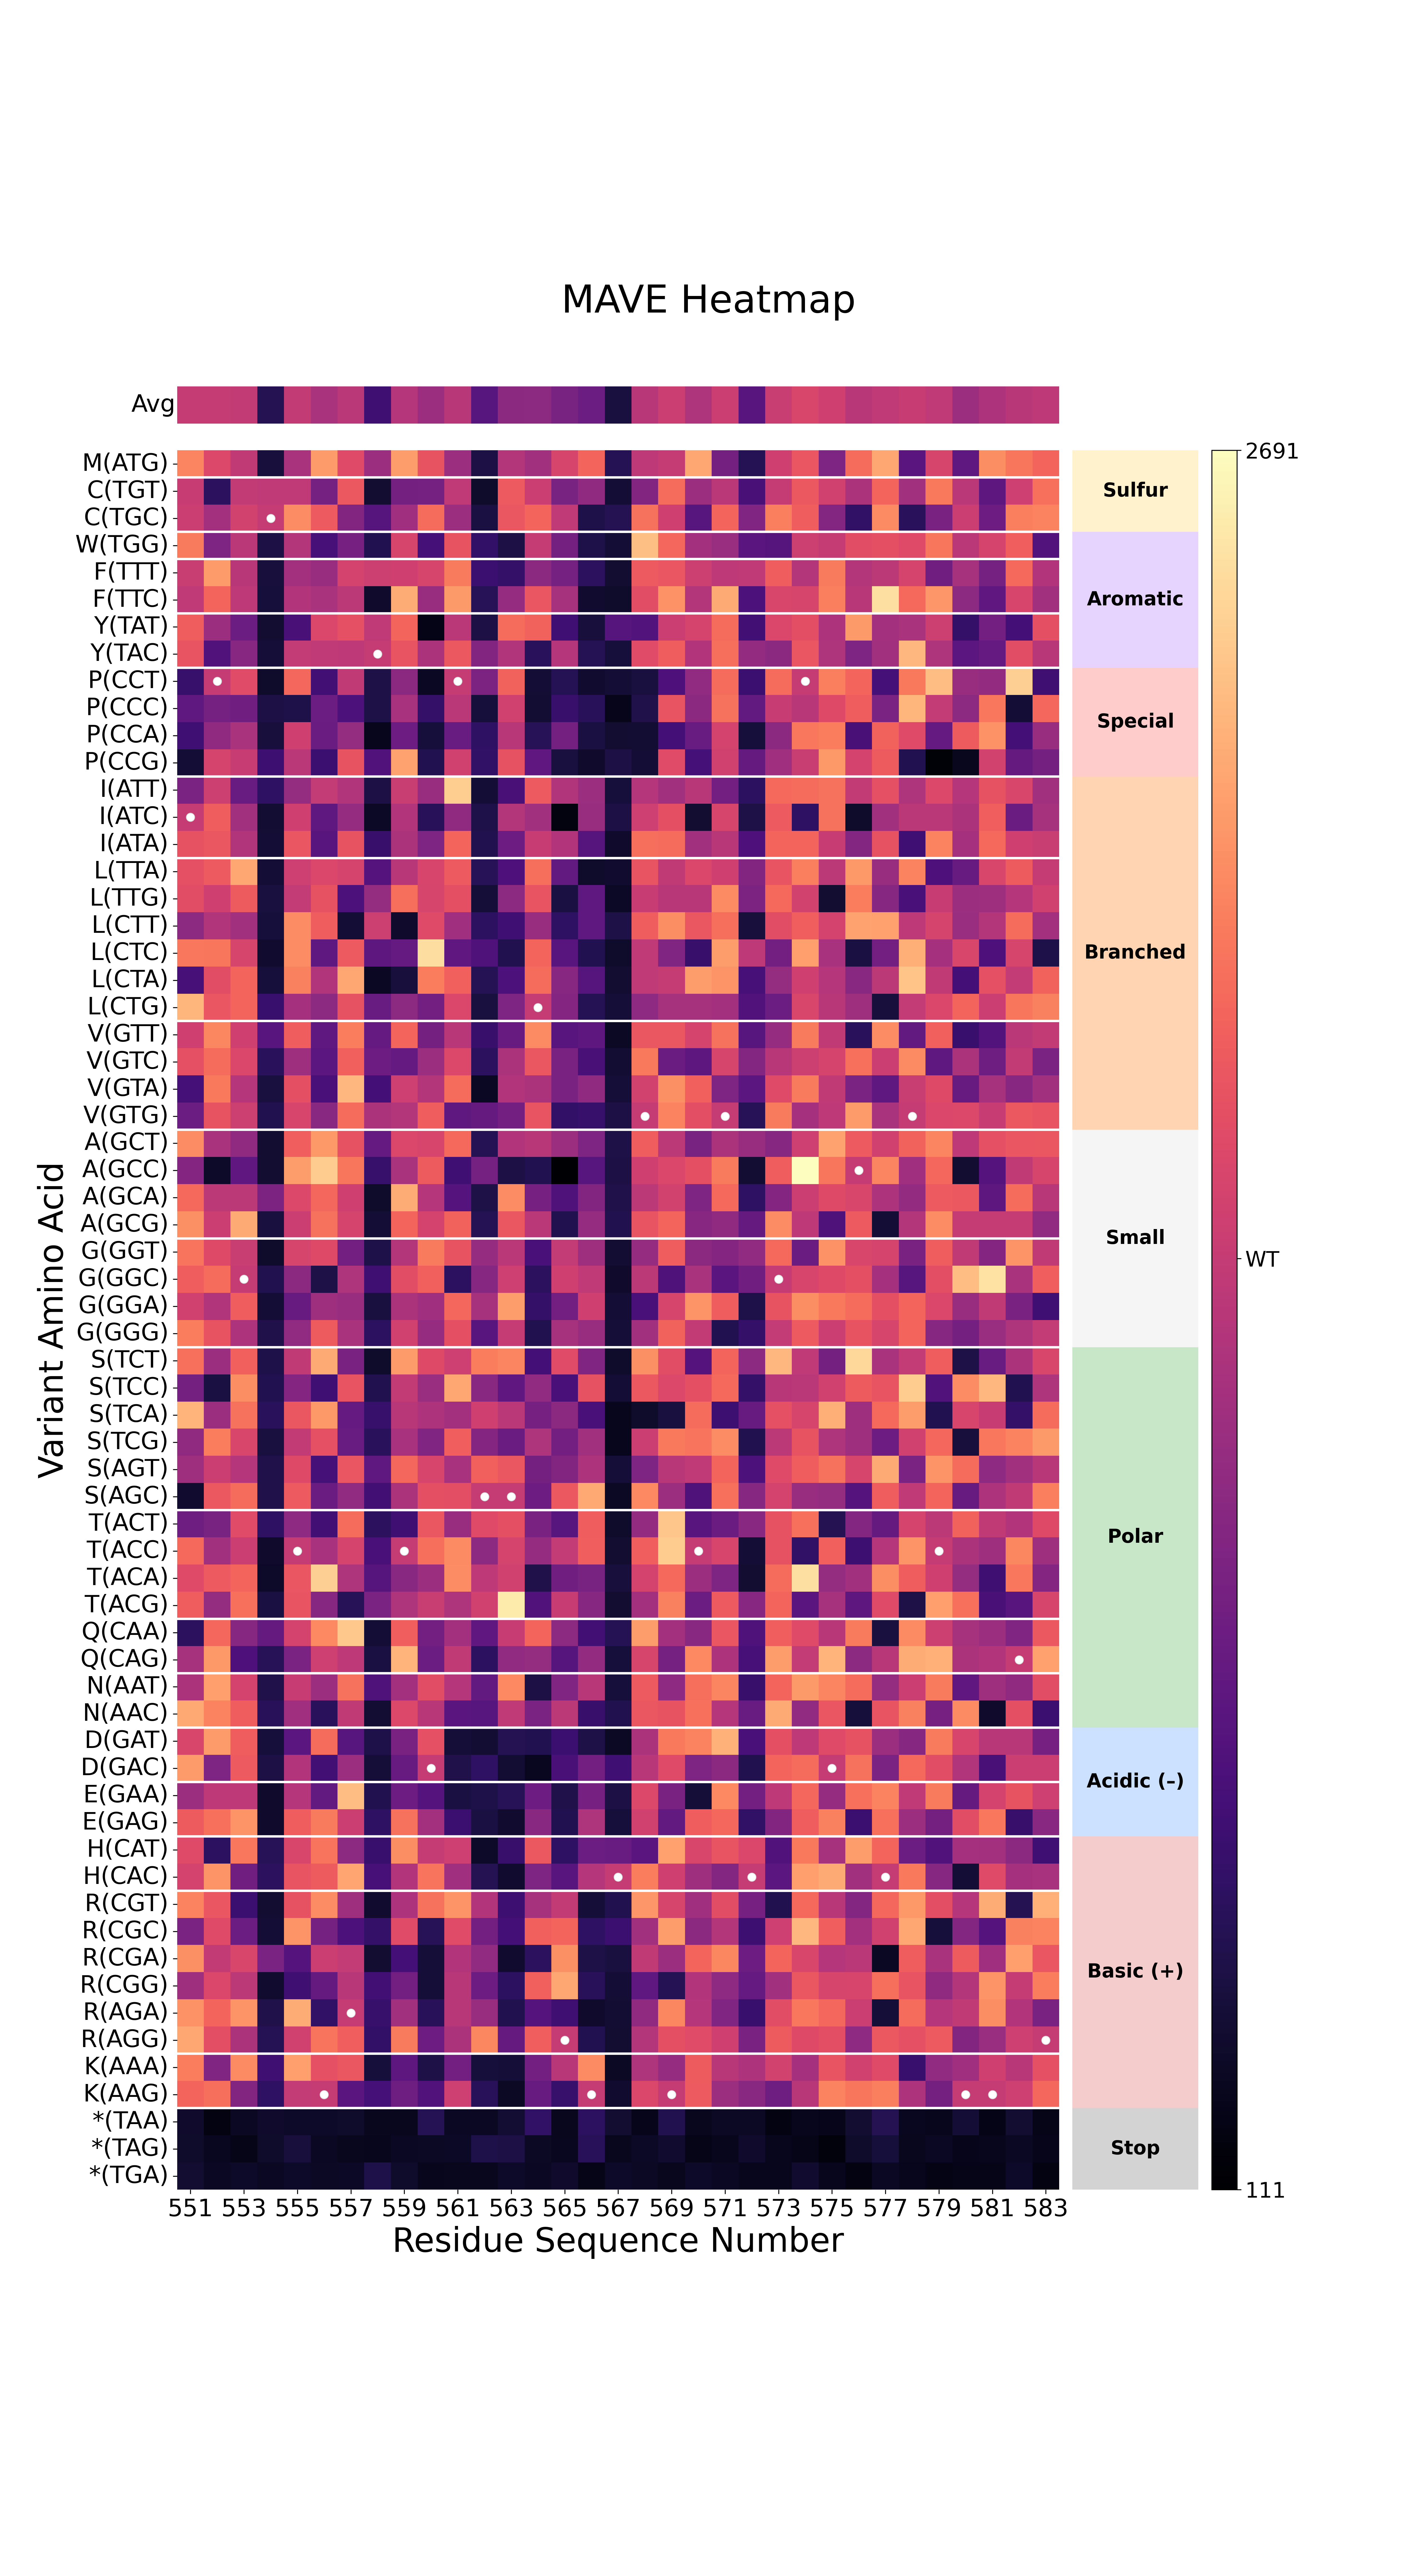

### Amino-acid heatmap (`demo_aa_heatmap.png`)

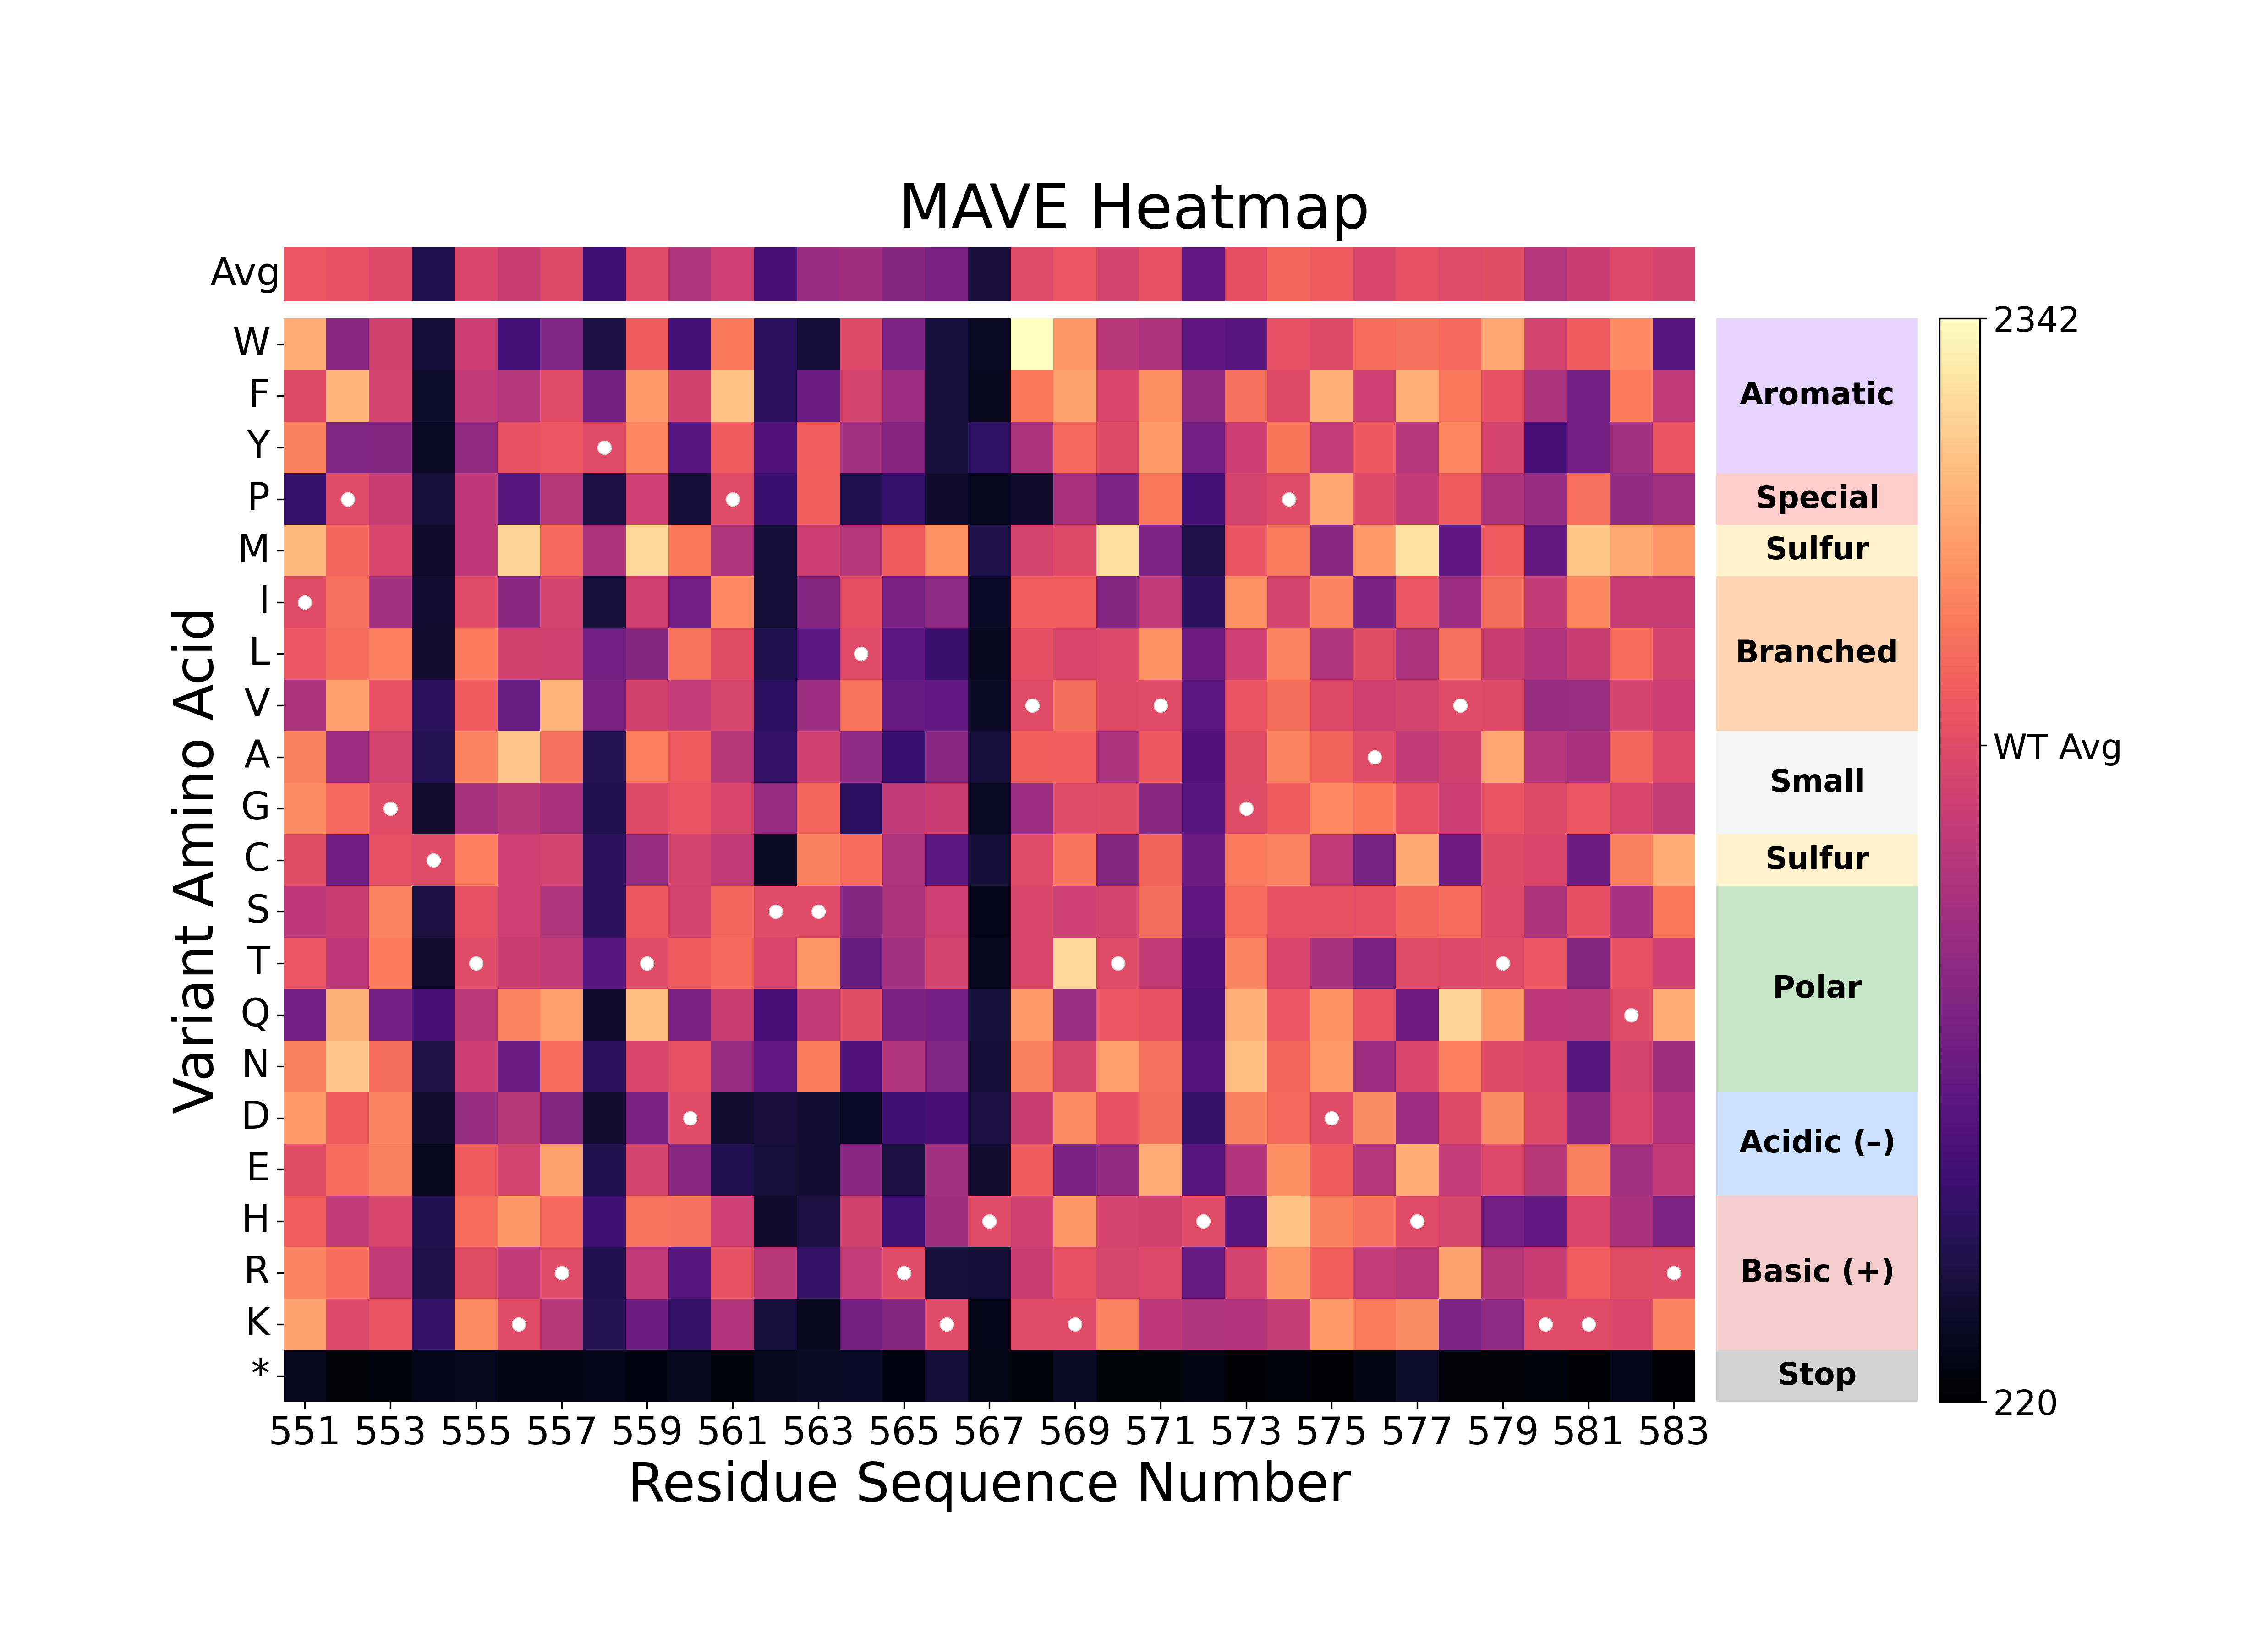

In [7]:
if not codon_heatmap_file.exists():
    print(f"No codon heatmap image found at {codon_heatmap_file}.")
else:
    display(Markdown(f"### Codon heatmap (`{codon_heatmap_file.name}`)"))
    display(Image(filename=str(codon_heatmap_file)))

if not aa_heatmap_file.exists():
    print(f"No amino-acid heatmap image found at {aa_heatmap_file}.")
else:
    display(Markdown(f"### Amino-acid heatmap (`{aa_heatmap_file.name}`)"))
    display(Image(filename=str(aa_heatmap_file)))
